# NLP on Ancient Egyptian Texts

This project applies modern NLP methods to English translations of ancient Egyptian texts. The goal is to explore thematic structure within funerary texts and compare funerary writing with mythic narrative texts.

The project is divided into four parts:

1. Topic modeling on *Book of the Dead* chapters  
2. Embedding-based clustering and semantic search  
3. Genre classification with sentence embeddings  
4. A small neural network classifier trained with backpropagation

## Project 1: Topic Modeling on Book of the Dead Chapters

In this section, I load selected Book of the Dead chapters, clean the text, and use TF-IDF and Latent Dirichlet Allocation (LDA) to identify recurring themes.

### Load All Your Files

In [1]:
import os
import pandas as pd

In [2]:
folder_path = "Downloads/book_of_dead_texts"

documents = []

for filename in os.listdir(folder_path):

    if filename.endswith(".txt"):

        with open(os.path.join(folder_path, filename), "r", encoding="utf-8") as f:
            text = f.read()

        documents.append({
            "id": filename.replace(".txt",""),
            "text": text
        })

df = pd.DataFrame(documents)

df.head(8)

,id,text
0,chapter1,A HYMN OF PRAISE TO RA WHEN HE RISETH IN THE E...
1,chapter3,"Osiris, the scribe Ani, saith:[1] ""My heart my..."
2,chapter2,"Glory be to Osiris Un-nefer, the great god wit..."
3,chapter7_10,HERE BEGIN THE PRAISES AND GLORIFYINGS[2] OF C...
4,chapter5_6,HERE BEGIN THE CHAPTERS OF COMING FORTH BY DAY...
5,chapter4,"Saith Horus, the son of Isis: ""I have come unt..."
6,chapter11_12,(I) THE FIRST ARIT. The name of the doorkeeper...
7,chapter13,"Hail Thoth, who madest Osiris (2) victorious o..."


### Basic Exploration (EDA)

In [3]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

df.sort_values("word_count", ascending=False)

,id,text,word_count
6,chapter11_12,(I) THE FIRST ARIT. The name of the doorkeeper...,1234
7,chapter13,"Hail Thoth, who madest Osiris (2) victorious o...",520
1,chapter3,"Osiris, the scribe Ani, saith:[1] ""My heart my...",214
5,chapter4,"Saith Horus, the son of Isis: ""I have come unt...",178
4,chapter5_6,HERE BEGIN THE CHAPTERS OF COMING FORTH BY DAY...,140
0,chapter1,A HYMN OF PRAISE TO RA WHEN HE RISETH IN THE E...,118
2,chapter2,"Glory be to Osiris Un-nefer, the great god wit...",82
3,chapter7_10,HERE BEGIN THE PRAISES AND GLORIFYINGS[2] OF C...,33


In [4]:
import re
import nltk
from nltk.corpus import stopwords

In [5]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /Users/juhi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"\[\d+\]", "", text)

    text = re.sub(r"\(\d+\)", "", text)

    text = re.sub(r"[^a-z\s]", "", text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

In [7]:
df["clean_text"]

0    hymn praise ra riseth eastern part heaven beho...
1    osiris scribe ani saith heart mother heart mot...
2    glory osiris unnefer great god within abydos k...
3    begin praises glorifyings coming going gloriou...
4    begin chapters coming forth day songs praise g...
5    saith horus son isis come unto thee unnefer br...
6    first arit name doorkeeper sekhethraashtaru na...
7    hail thoth madest osiris victorious enemies ma...
Name: clean_text, dtype: object

### Generate N-grams

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1,2))

X = vectorizer.fit_transform(df["clean_text"])
words = vectorizer.get_feature_names_out()

print(words[:50])

['aaa' 'aaa saith' 'aamaakheru' 'aamaakheru name' 'abtu' 'abtu night'
 'abtu opened' 'abydos' 'abydos king' 'according' 'according decree'
 'adore' 'adore thee' 'advance' 'advance entreat' 'advancing'
 'advancing may' 'afar' 'afar slaughtering' 'ale' 'ale let' 'along'
 'along created' 'along seventh' 'along way' 'aloud' 'aloud man' 'amenta'
 'amenta coming' 'amenta saith' 'amentet' 'amentet underworld' 'among'
 'among ancient' 'among gods' 'ancestress' 'ancestress osiris' 'ancient'
 'ancient one' 'anhri' 'anhri name' 'ani' 'ani cometh' 'ani hath'
 'ani saith' 'ani scribe' 'ani triumphant' 'ani unto' 'ani victorious'
 'ankhfemfent']


### TF-IDF

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df["clean_text"])
words = vectorizer.get_feature_names_out()

words

array(['aaa', 'aamaakheru', 'abtu', 'abydos', 'according', 'adore',
       'advance', 'advancing', 'afar', 'ale', 'along', 'aloud', 'amenta',
       'amentet', 'among', 'ancestress', 'ancient', 'anhri', 'ani',
       'ankhfemfent', 'annu', 'anubis', 'apep', 'arising', 'arisutchesef',
       'arit', 'arm', 'art', 'atekaukehaqkheru', 'ateshra', 'aught',
       'avenged', 'avenger', 'away', 'back', 'backbone', 'balance',
       'battle', 'bear', 'beautiful', 'begin', 'beginning', 'behind',
       'behold', 'beings', 'belonged', 'beloved', 'blazing', 'body',
       'bones', 'born', 'breadth', 'breath', 'bright', 'bringing',
       'brought', 'building', 'bull', 'business', 'cakes', 'cannot',
       'cause', 'causeth', 'chapter', 'chapters', 'chiefest', 'clothe',
       'clothed', 'clotheth', 'coffin', 'columns', 'come', 'cometh',
       'coming', 'comingforth', 'command', 'companions', 'company',
       'content', 'created', 'createth', 'creator', 'crook', 'crown',
       'crowned', 'crown

### Topic modeling with LDA

In [10]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

,n_components,3
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


### Extract the top words in each topic

In [11]:
words = vectorizer.get_feature_names_out()

for topic in lda.components_:
    print([words[i] for i in topic.argsort()[-10:]])

['begin', 'glorious', 'mouth', 'enemies', 'neterkhert', 'ani', 'name', 'victorious', 'coming', 'osiris']
['saith', 'unto', 'presence', 'thee', 'god', 'lord', 'osiris', 'may', 'heart', 'hath']
['riseth', 'thy', 'gods', 'mother', 'nut', 'thou', 'homage', 'khepera', 'two', 'thee']


### Which Chapter Belongs To Which Topic?

In [12]:
topic_results = lda.transform(X)

topic_df = pd.DataFrame(topic_results)

topic_df["chapter"] = df["id"]

topic_df

,0,1,2,chapter
0,0.046102,0.046978,0.906920,chapter1
1,0.043038,0.915123,0.041840,chapter3
2,0.049020,0.902119,0.048861,chapter2
3,0.844520,0.078031,0.077449,chapter7_10
4,0.897885,0.052374,0.049741,chapter5_6
5,0.045071,0.911849,0.043081,chapter4
6,0.923215,0.039153,0.037632,chapter11_12
7,0.904363,0.048312,0.047325,chapter13


In [13]:
import numpy as np

topic_df["main_topic"] = topic_results.argmax(axis=1)

topic_labels = {
    0: "Underworld gates & Osiris",
    1: "Judgment, heart & petitions",
    2: "Solar hymn to Ra"
}

topic_df["topic_label"] = topic_df["main_topic"].map(topic_labels)

topic_df = topic_df[["chapter", 0, 1, 2, "main_topic", "topic_label"]]
topic_df


,chapter,0,1,2,main_topic,topic_label
0,chapter1,0.046102,0.046978,0.906920,2,Solar hymn to Ra
1,chapter3,0.043038,0.915123,0.041840,1,"Judgment, heart & petitions"
2,chapter2,0.049020,0.902119,0.048861,1,"Judgment, heart & petitions"
3,chapter7_10,0.844520,0.078031,0.077449,0,Underworld gates & Osiris
4,chapter5_6,0.897885,0.052374,0.049741,0,Underworld gates & Osiris
5,chapter4,0.045071,0.911849,0.043081,1,"Judgment, heart & petitions"
6,chapter11_12,0.923215,0.039153,0.037632,0,Underworld gates & Osiris
7,chapter13,0.904363,0.048312,0.047325,0,Underworld gates & Osiris


### Simple Visualization

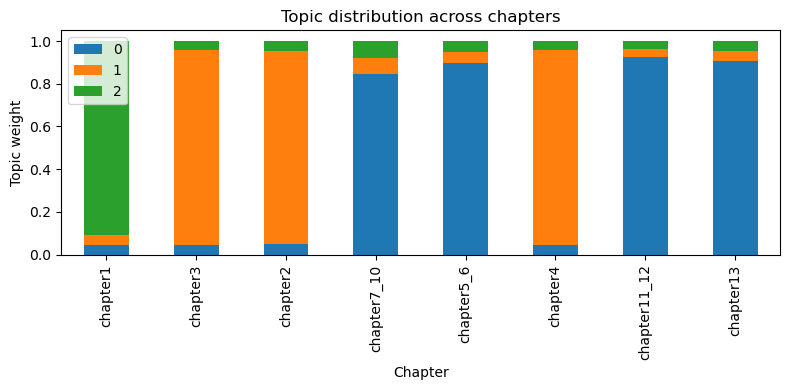

In [14]:
import matplotlib.pyplot as plt


plot_df = topic_df.set_index("chapter")[[0, 1, 2]]
plot_df.plot(kind="bar", stacked=True, figsize=(8,4))

plt.title("Topic distribution across chapters")
plt.ylabel("Topic weight")
plt.xlabel("Chapter")
plt.tight_layout()
plt.show()

### Project 1 Results

The LDA model identified three broad themes:
- Solar praise and hymnic language
- Judgment, the heart, and petitions
- Underworld passages and Osirian material

These themes are consistent with the ritual and theological content of the selected funerary chapters.

## Project 2: Embedding-Based Clustering and Semantic Search

In this section, I use sentence-transformer embeddings to represent each funerary chapter in semantic space. 
This makes it possible to compare chapters by meaning, cluster them, visualize them, and perform semantic search.

### Load sentence transformer

In [15]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
embeddings = model.encode(df["clean_text"].tolist())

In [17]:
embeddings

array([[-0.03144639,  0.01150497,  0.01322452, ..., -0.00331577,
         0.05012842, -0.02881567],
       [-0.02752481,  0.03426477, -0.01147275, ...,  0.0103849 ,
         0.03327489, -0.08373988],
       [-0.01051031,  0.08573232,  0.00141978, ..., -0.03719105,
         0.04510387, -0.05664541],
       ...,
       [-0.03787036,  0.06127479, -0.01121566, ...,  0.007397  ,
         0.08277462, -0.06820985],
       [-0.02610978, -0.00625582, -0.02824995, ..., -0.03405733,
         0.0281066 ,  0.01575894],
       [-0.0487228 ,  0.0504981 ,  0.00258783, ..., -0.0107073 ,
        -0.00103056, -0.01012285]], shape=(8, 384), dtype=float32)

### Compare chapters by meaning

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df["id"],
    columns=df["id"]
)

similarity_df

id,chapter1,chapter3,chapter2,chapter7_10,chapter5_6,chapter4,chapter11_12,chapter13
id,,,,,,,,
chapter1,1.000000,0.641366,0.600766,0.498927,0.664760,0.700445,0.544040,0.588453
chapter3,0.641366,1.000000,0.529334,0.387015,0.553567,0.768258,0.570230,0.609617
chapter2,0.600766,0.529334,1.000000,0.472030,0.531578,0.590209,0.451614,0.580893
chapter7_10,0.498927,0.387015,0.472030,1.000000,0.618498,0.420121,0.382904,0.465249
chapter5_6,0.664760,0.553567,0.531578,0.618498,1.000000,0.588898,0.477758,0.605435
chapter4,0.700445,0.768258,0.590209,0.420121,0.588898,1.000000,0.541001,0.685704
chapter11_12,0.544040,0.570230,0.451614,0.382904,0.477758,0.541001,1.000000,0.577687
chapter13,0.588453,0.609617,0.580893,0.465249,0.605435,0.685704,0.577687,1.000000


### KMeans clustering

In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(embeddings)

df["embedding_cluster"] = clusters

df[["id","embedding_cluster"]]

,id,embedding_cluster
0,chapter1,1
1,chapter3,1
2,chapter2,1
3,chapter7_10,0
4,chapter5_6,0
5,chapter4,1
6,chapter11_12,2
7,chapter13,2


### Compare LDA topics and embedding clusters

In [20]:
comparison_df = df[["id"]].copy()
comparison_df["lda_topic"] = topic_df["main_topic"].values
comparison_df["lda_label"] = topic_df["topic_label"].values
comparison_df["embedding_cluster"] = df["embedding_cluster"].values

comparison_df

,id,lda_topic,lda_label,embedding_cluster
0,chapter1,2,Solar hymn to Ra,1
1,chapter3,1,"Judgment, heart & petitions",1
2,chapter2,1,"Judgment, heart & petitions",1
3,chapter7_10,0,Underworld gates & Osiris,0
4,chapter5_6,0,Underworld gates & Osiris,0
5,chapter4,1,"Judgment, heart & petitions",1
6,chapter11_12,0,Underworld gates & Osiris,2
7,chapter13,0,Underworld gates & Osiris,2


### PCA plot

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [22]:
pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(embeddings)

In [23]:
reduced_embeddings

array([[-0.02852376, -0.15660875],
       [-0.34801394, -0.08152812],
       [ 0.06253721, -0.31138387],
       [ 0.6535385 ,  0.12789838],
       [ 0.29889104, -0.03205087],
       [-0.29061803, -0.20202267],
       [-0.2318061 ,  0.604667  ],
       [-0.11600483,  0.05102904]], dtype=float32)

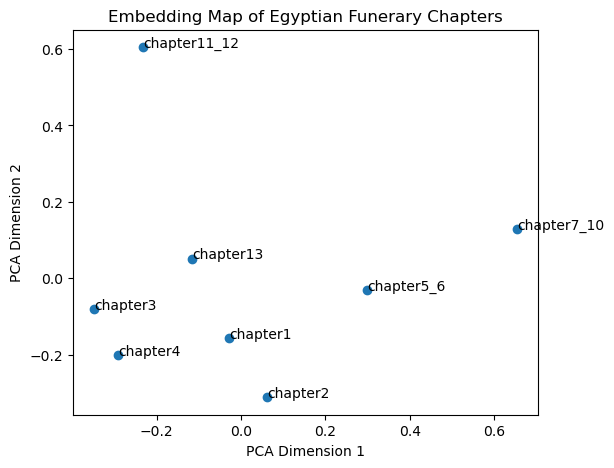

In [24]:
plt.figure(figsize=(6,5))

plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1])

for i, chapter in enumerate(df["id"]):
    plt.text(reduced_embeddings[i,0], reduced_embeddings[i,1], chapter)

plt.title("Embedding Map of Egyptian Funerary Chapters")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")

plt.show()

### UMAP plot

In [25]:
!pip install umap-learn

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


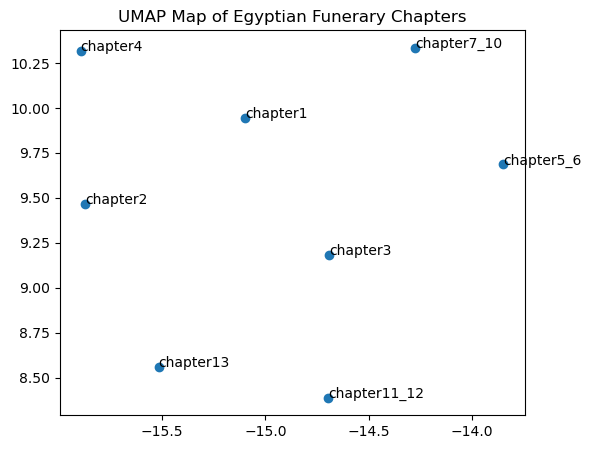

In [26]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(random_state=42)

umap_embeddings = reducer.fit_transform(embeddings)

plt.figure(figsize=(6,5))

plt.scatter(umap_embeddings[:,0], umap_embeddings[:,1])

for i, chapter in enumerate(df["id"]):
    plt.text(umap_embeddings[i,0], umap_embeddings[i,1], chapter)

plt.title("UMAP Map of Egyptian Funerary Chapters")

plt.show()

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


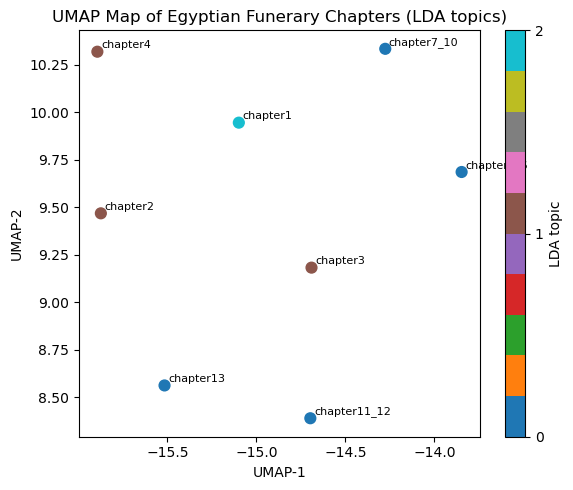

In [27]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(random_state=42)
umap_embeddings = reducer.fit_transform(embeddings)

plt.figure(figsize=(6,5))

scatter = plt.scatter(
    umap_embeddings[:,0],
    umap_embeddings[:,1],
    c=topic_df["main_topic"],   # 0,1,2 from LDA
    cmap="tab10",
    s=60
)

for i, chapter in enumerate(df["id"]):
    plt.text(umap_embeddings[i,0]+0.02, umap_embeddings[i,1]+0.02, chapter, fontsize=8)

plt.title("UMAP Map of Egyptian Funerary Chapters (LDA topics)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(scatter, ticks=[0,1,2], label="LDA topic")
plt.tight_layout()
plt.show()



### Semantic search function

In [28]:
def semantic_search(query, model, embeddings, df, top_k=3):
    
    query_embedding = model.encode([query])

    
    similarities = cosine_similarity(query_embedding, embeddings)[0]

    
    top_indices = similarities.argsort()[-top_k:][::-1]

    
    results = df.iloc[top_indices][["id", "text"]].copy()
    results["similarity_score"] = similarities[top_indices]

    return results

In [29]:
results = semantic_search("judgment of the heart", model, embeddings, df, top_k=3)
for _, row in results.iterrows():
    print(row["id"], f"(score={row['similarity_score']:.3f})")
    print(row["text"][:300], "...\n")


chapter3 (score=0.404)
Osiris, the scribe Ani, saith:[1] "My heart my mother, my heart my mother, my heart my coming into being! May there be nothing to resist me at [my] judgment; may there be no opposition to me from the Tchatcha;[2] may there be no parting of thee from me in the presence of him who keepeth the scales!  ...

chapter2 (score=0.259)
Glory be to Osiris Un-nefer, the great god within Abydos, king of eternity, lord of the everlasting, who passeth through millions of years in his existence. Eldest son of the womb (2) of Nut, engendered by Seb the Erpat,[1] lord of the crowns of the North and South, lord of the lofty white crown. As ...

chapter4 (score=0.227)
Saith Horus, the son of Isis: "I have come unto thee, O Unnefer, and I have brought the Osiris Ani unto thee. His heart is [found] righteous coming forth from the balance, and it hath not sinned against god or goddess. Thoth hath weighed it according to the decree uttered unto him by the company {p. ...



### Query on map interface

In [30]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd

# Fit PCA once on chapter embeddings
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 1. Semantic search function
def semantic_search(query, model, embeddings, df, top_k=3):
    query_embedding = model.encode([query])
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    top_indices = similarities.argsort()[-top_k:][::-1]

    results = df.iloc[top_indices][["id", "text"]].copy()
    results["similarity_score"] = similarities[top_indices]
    results["preview"] = results["text"].str[:250] + "..."
    results = results[["id", "similarity_score", "preview"]]

    return results, query_embedding, top_indices

In [31]:
def plot_query_with_results(query, query_embedding, df, top_indices):
    query_reduced = pca.transform(query_embedding)

    plt.figure(figsize=(7,6))

    # all chapters
    plt.scatter(
        reduced_embeddings[:,0],
        reduced_embeddings[:,1],
        s=60,
        alpha=0.6,
        label="All chapters"
    )

    # highlight top results
    plt.scatter(
        reduced_embeddings[top_indices,0],
        reduced_embeddings[top_indices,1],
        s=140,
        label="Top results"
    )

    # label all chapters
    for i, chapter in enumerate(df["id"]):
        plt.text(
            reduced_embeddings[i,0] + 0.01,
            reduced_embeddings[i,1] + 0.01,
            chapter,
            fontsize=8
        )

    # query point
    plt.scatter(
        query_reduced[:,0],
        query_reduced[:,1],
        marker="X",
        s=180,
        label="Query"
    )

    plt.text(
        query_reduced[0,0] + 0.01,
        query_reduced[0,1] + 0.01,
        "QUERY",
        fontsize=10
    )

    plt.title(f'Semantic Search Map: "{query}"')
    plt.xlabel("PCA-1")
    plt.ylabel("PCA-2")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [32]:
def run_search(query, top_k=3):
    results, query_embedding, top_indices = semantic_search(
        query, model, embeddings, df, top_k=top_k
    )

    print("Query:", query)
    display(results)

    plot_query_with_results(query, query_embedding, df, top_indices)

Query: judgment of the heart


,id,similarity_score,preview
1,chapter3,0.403694,"Osiris, the scribe Ani, saith:[1] ""My heart my..."
2,chapter2,0.258924,"Glory be to Osiris Un-nefer, the great god wit..."
5,chapter4,0.227029,"Saith Horus, the son of Isis: ""I have come unt..."


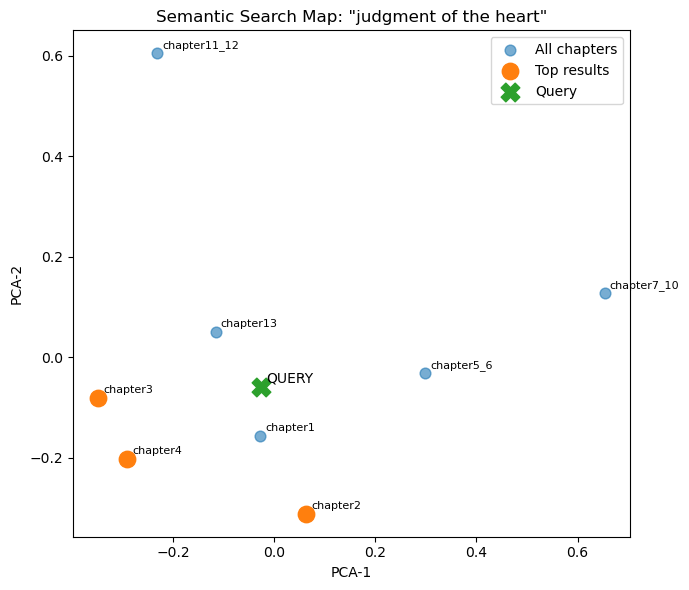

In [33]:
run_search("judgment of the heart", top_k=3)

### Project 2 Results

The embedding-based analysis shows that semantically related chapters occupy nearby regions in vector space. 
Cosine similarity and clustering reveal meaningful relationships between chapters, while semantic search successfully retrieves passages related to concepts such as judgment of the heart.

# Project 3: Funerary vs Mythic Classification with Sentence Embeddings

In this section, I combine funerary texts with mythic Egyptian texts and test whether sentence embeddings can distinguish the two genres.

In [34]:
import os
import pandas as pd

funerary_folder = "Downloads/book_of_dead_texts"
mythic_folder = "Downloads/egypt_myth_texts"

data = []

# Load funerary texts
for filename in os.listdir(funerary_folder):
    if filename.endswith(".txt"):
        filepath = os.path.join(funerary_folder, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            text = f.read()

        data.append({
            "id": filename.replace(".txt", ""),
            "genre": "funerary",
            "text": text
        })

# Load mythic texts
for filename in os.listdir(mythic_folder):
    if filename.endswith(".txt"):
        filepath = os.path.join(mythic_folder, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            text = f.read()

        data.append({
            "id": filename.replace(".txt", ""),
            "genre": "mythic",
            "text": text
        })

genre_df = pd.DataFrame(data)

genre_df

,id,genre,text
0,chapter1,funerary,A HYMN OF PRAISE TO RA WHEN HE RISETH IN THE E...
1,chapter3,funerary,"Osiris, the scribe Ani, saith:[1] ""My heart my..."
2,chapter2,funerary,"Glory be to Osiris Un-nefer, the great god wit..."
3,chapter7_10,funerary,HERE BEGIN THE PRAISES AND GLORIFYINGS[2] OF C...
4,chapter5_6,funerary,HERE BEGIN THE CHAPTERS OF COMING FORTH BY DAY...
5,chapter4,funerary,"Saith Horus, the son of Isis: ""I have come unt..."
6,chapter11_12,funerary,(I) THE FIRST ARIT. The name of the doorkeeper...
7,chapter13,funerary,"Hail Thoth, who madest Osiris (2) victorious o..."
8,legend_01_princess_demon,mythic,THE PRINCESS AND THE DEMON\nIt was in the reig...
9,legend_08_battles_horus,mythic,THE BATTLES OF HORUS\nIt was in the three hund...


In [35]:
genre_df["genre"].value_counts()

genre
funerary    8
mythic      8
Name: count, dtype: int64

In [36]:
genre_df["clean_text"] = genre_df["text"].apply(clean_text)

genre_df[["id", "genre", "clean_text"]].head()

,id,genre,clean_text
0,chapter1,funerary,hymn praise ra riseth eastern part heaven beho...
1,chapter3,funerary,osiris scribe ani saith heart mother heart mot...
2,chapter2,funerary,glory osiris unnefer great god within abydos k...
3,chapter7_10,funerary,begin praises glorifyings coming going gloriou...
4,chapter5_6,funerary,begin chapters coming forth day songs praise g...


In [37]:
genre_embeddings = model.encode(genre_df["clean_text"].tolist())

genre_embeddings.shape

(16, 384)

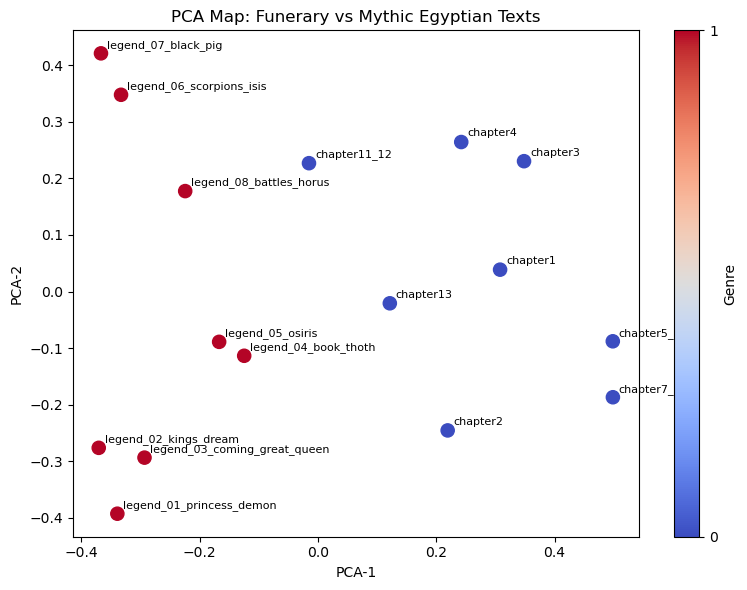

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

genre_pca = PCA(n_components=2)
genre_reduced = genre_pca.fit_transform(genre_embeddings)

genre_colors = genre_df["genre"].map({
    "funerary": 0,
    "mythic": 1
})

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    genre_reduced[:, 0],
    genre_reduced[:, 1],
    c=genre_colors,
    cmap="coolwarm",
    s=90
)

for i, label in enumerate(genre_df["id"]):
    plt.text(
        genre_reduced[i, 0] + 0.01,
        genre_reduced[i, 1] + 0.01,
        label,
        fontsize=8
    )

plt.title("PCA Map: Funerary vs Mythic Egyptian Texts")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.colorbar(scatter, ticks=[0,1], label="Genre")
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


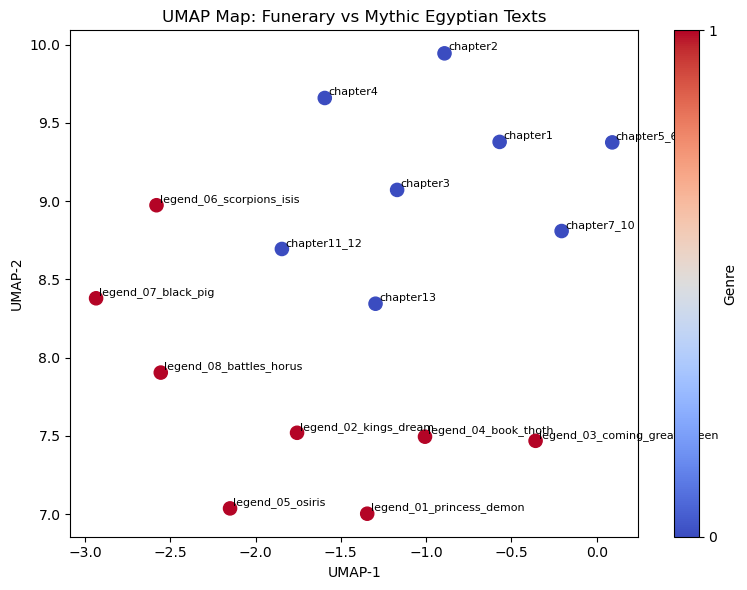

In [39]:
import umap
import matplotlib.pyplot as plt

genre_reducer = umap.UMAP(random_state=42)
genre_umap = genre_reducer.fit_transform(genre_embeddings)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    genre_umap[:, 0],
    genre_umap[:, 1],
    c=genre_colors,
    cmap="coolwarm",
    s=90
)

for i, label in enumerate(genre_df["id"]):
    plt.text(
        genre_umap[i, 0] + 0.02,
        genre_umap[i, 1] + 0.02,
        label,
        fontsize=8
    )

plt.title("UMAP Map: Funerary vs Mythic Egyptian Texts")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(scatter, ticks=[0,1], label="Genre")
plt.tight_layout()
plt.show()

In [40]:
from sklearn.cluster import KMeans

genre_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
genre_clusters = genre_kmeans.fit_predict(genre_embeddings)

genre_df["cluster"] = genre_clusters

genre_df[["id", "genre", "cluster"]]

,id,genre,cluster
0,chapter1,funerary,0
1,chapter3,funerary,0
2,chapter2,funerary,0
3,chapter7_10,funerary,0
4,chapter5_6,funerary,0
5,chapter4,funerary,0
6,chapter11_12,funerary,0
7,chapter13,funerary,0
8,legend_01_princess_demon,mythic,1
9,legend_08_battles_horus,mythic,1


### Encode labels

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(genre_df["genre"])   # funerary/mythic -> 0/1
X = genre_embeddings

print(label_encoder.classes_)

['funerary' 'mythic']


### Logistic regression with cross-validation

In [42]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000)

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
log_scores = cross_val_score(log_reg, X, y, cv=cv, scoring="accuracy")

print("Logistic Regression CV accuracies:", log_scores)
print("Mean accuracy:", log_scores.mean())

Logistic Regression CV accuracies: [1.   0.75 1.   1.  ]
Mean accuracy: 0.9375


### Linear SVM baseline

In [43]:
from sklearn.svm import SVC

svm_clf = SVC(kernel="linear")

svm_scores = cross_val_score(svm_clf, X, y, cv=cv, scoring="accuracy")

print("Linear SVM CV accuracies:", svm_scores)
print("Mean accuracy:", svm_scores.mean())

Linear SVM CV accuracies: [1.   0.75 1.   1.  ]
Mean accuracy: 0.9375


### Fit one final model for inspection

In [44]:
log_reg.fit(X, y)
genre_df["predicted_genre_logreg"] = label_encoder.inverse_transform(log_reg.predict(X))

genre_df[["id", "genre", "predicted_genre_logreg"]]

,id,genre,predicted_genre_logreg
0,chapter1,funerary,funerary
1,chapter3,funerary,funerary
2,chapter2,funerary,funerary
3,chapter7_10,funerary,funerary
4,chapter5_6,funerary,funerary
5,chapter4,funerary,funerary
6,chapter11_12,funerary,funerary
7,chapter13,funerary,funerary
8,legend_01_princess_demon,mythic,mythic
9,legend_08_battles_horus,mythic,mythic


### Confusion matrix

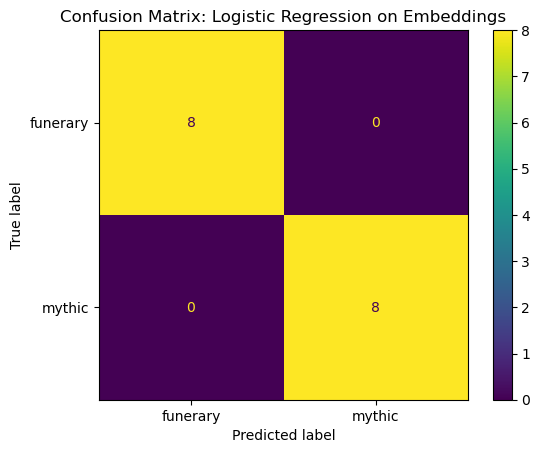

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = log_reg.predict(X)
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title("Confusion Matrix: Logistic Regression on Embeddings")
plt.show()

### Classification report

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

    funerary       1.00      1.00      1.00         8
      mythic       1.00      1.00      1.00         8

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



### Project 3 Results

Funerary and mythic texts separate clearly in embedding space. 
KMeans clustering divides the two genres cleanly in this dataset, and both logistic regression and linear SVM achieve a mean cross-validation accuracy of 93.75%.

This suggests that the embedding space captures strong genre differences between ritual funerary language and mythic narrative language.


Note: the confusion matrix and classification report are computed on the full dataset after fitting the model on all available examples. They are included for inspection, while the main evaluation result is the 4-fold cross-validation accuracy reported above.

## Project 4: Small Neural Network Classifier with Backpropagation

In this section, I reuse the sentence embeddings from Project 3 and train a small feed-forward neural network to classify texts as funerary or mythic. 
This demonstrates a learnable model trained with backpropagation.

### Train/test split

In [47]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.array(genre_embeddings, dtype=np.float32)
y = np.array(label_encoder.transform(genre_df["genre"]), dtype=np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(12, 384) (4, 384)


### Build tensors

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim

X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train).unsqueeze(1)

X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test).unsqueeze(1)

### Define the neural net

In [49]:
class GenreClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

model = GenreClassifier(input_dim=X.shape[1])
print(model)

GenreClassifier(
  (network): Sequential(
    (0): Linear(in_features=384, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


### Loss and optimizer

In [50]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training loop

In [51]:
num_epochs = 100
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()

    optimizer.zero_grad()
    train_outputs = model(X_train_tensor)
    train_loss = criterion(train_outputs, y_train_tensor)
    train_loss.backward()   # backprop
    optimizer.step()

    with torch.no_grad():
        model.eval()

        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor)

        train_preds = (torch.sigmoid(train_outputs) > 0.5).float()
        test_preds = (torch.sigmoid(test_outputs) > 0.5).float()

        train_acc = (train_preds.eq(y_train_tensor)).float().mean().item()
        test_acc = (test_preds.eq(y_test_tensor)).float().mean().item()

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss.item():.4f} | Test Loss: {test_loss.item():.4f} | "
              f"Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

Epoch 10/100 | Train Loss: 0.6741 | Test Loss: 0.6809 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 20/100 | Train Loss: 0.6402 | Test Loss: 0.6628 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 30/100 | Train Loss: 0.5891 | Test Loss: 0.6355 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 40/100 | Train Loss: 0.5168 | Test Loss: 0.5975 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 50/100 | Train Loss: 0.4238 | Test Loss: 0.5474 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 60/100 | Train Loss: 0.3191 | Test Loss: 0.4872 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 70/100 | Train Loss: 0.2192 | Test Loss: 0.4232 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 80/100 | Train Loss: 0.1396 | Test Loss: 0.3641 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 90/100 | Train Loss: 0.0860 | Test Loss: 0.3175 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 100/100 | Train Loss: 0.0539 | Test Loss: 0.2852 | Train Acc: 1.000 | Test Acc: 1.000


### Plot loss and accuracy

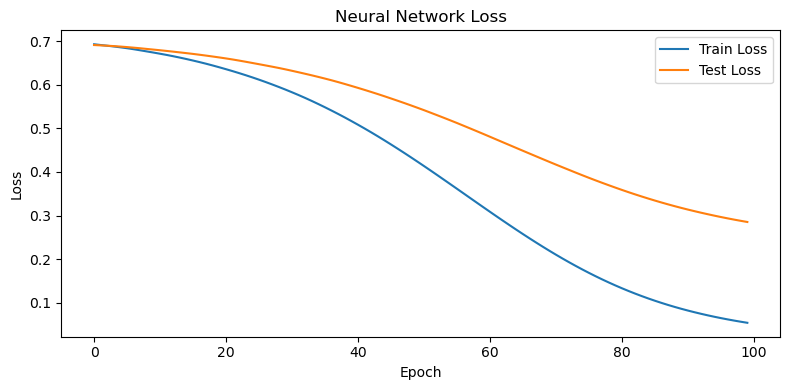

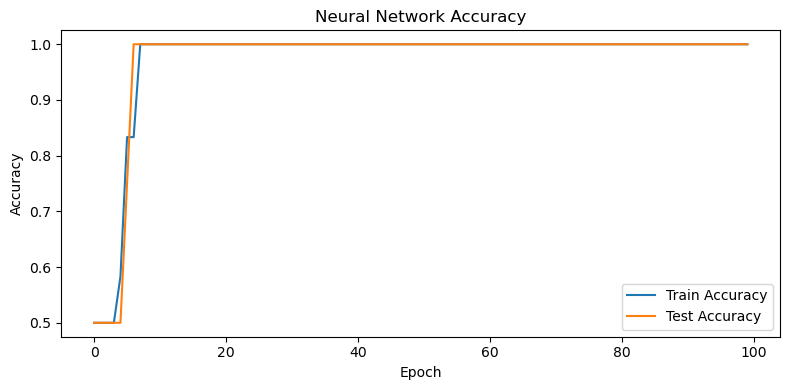

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Neural Network Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.title("Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### Final evaluation

In [53]:
from sklearn.metrics import classification_report, confusion_matrix

with torch.no_grad():
    final_outputs = model(X_test_tensor)
    final_preds = (torch.sigmoid(final_outputs) > 0.5).int().numpy().flatten()

print("Neural Net Test Predictions:", final_preds)
print("True Labels:", y_test.astype(int))

print(classification_report(y_test.astype(int), final_preds, target_names=label_encoder.classes_))
print(confusion_matrix(y_test.astype(int), final_preds))

Neural Net Test Predictions: [0 1 0 1]
True Labels: [0 1 0 1]
              precision    recall  f1-score   support

    funerary       1.00      1.00      1.00         2
      mythic       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

[[2 0]
 [0 2]]


## Project 4 Results

The neural network achieved 100% accuracy on this held-out test split, correctly classifying all four test documents.

Because the dataset is very small, this result should be interpreted cautiously. With only 16 total documents and 4 test examples, performance may vary across different train/test splits. Even so, the result shows that a small feed-forward neural network can learn the funerary-versus-mythic distinction from sentence embeddings.

Compared with the Project 3 linear baselines, the neural network also performed very strongly. However, the small dataset makes it difficult to conclude that the neural model is definitively better than simpler classifiers.

## Final Conclusion

This project applied modern NLP methods to English translations of ancient Egyptian texts. Topic modeling revealed meaningful thematic structure within *Book of the Dead* chapters, including solar praise, judgment language, and underworld or Osirian material.

Sentence embeddings supported clustering, visualization, and semantic search within the funerary corpus. Across the broader corpus, embeddings clearly separated funerary texts from mythic texts.

For genre classification, logistic regression and linear SVM achieved a mean cross-validation accuracy of 93.75%, showing that the two genres are highly separable in embedding space. A small neural network trained with backpropagation also learned the distinction and achieved 100% accuracy on the held-out test split used in this notebook. Because the dataset is very small, this result should be interpreted cautiously.

A limitation of the project is that it analyzes English translations rather than original ancient Egyptian texts. Therefore, the findings reflect translated textual style and theme rather than a direct linguistic model of ancient Egyptian itself.